# Sticker Colour Classifier — Phase 1

**Goal:** given a small image of ONE sticker, predict its colour:
`white, yellow, red, orange, blue, green` (6 classes).

We'll build two versions and compare them:
1. **Baseline (no ML):** hand-written rules on HSV colour values.
2. **CNN:** a small convolutional neural network trained with PyTorch.

If the CNN can't beat the simple baseline, it isn't earning its complexity.

## Roadmap (one concept at a time)
- [ ] Step 0 — Check the environment (below)
- [ ] Step 1 — Tensors: how PyTorch stores images as numbers
- [ ] Step 2 — Dataset: collect and label sticker images
- [ ] Step 3 — Baseline: HSV rules with OpenCV
- [ ] Step 4 — The CNN: layers and the forward pass
- [ ] Step 5 — Training loop: loss, gradients, optimizer
- [ ] Step 6 — Evaluation: accuracy, confusion matrix, baseline vs CNN

## Step 0 — Check the environment
Run this cell. Every import should work, and it should tell you which device PyTorch will use.

In [1]:
import sys
import torch
import torchvision
import cv2
import matplotlib

print("Python      ", sys.version.split()[0])
print("PyTorch     ", torch.__version__)
print("torchvision ", torchvision.__version__)
print("OpenCV      ", cv2.__version__)
print("matplotlib  ", matplotlib.__version__)

# "mps" = Apple-silicon GPU, "cuda" = NVIDIA GPU, "cpu" = fallback
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print("Device      ", device)

Python       3.11.16
PyTorch      2.14.0
torchvision  0.29.0
OpenCV       5.0.0
matplotlib   3.11.2
Device       mps


In [3]:
img = cv2.imread("data/samples/orange_sticker.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print(img[32, 32])
print(img.shape)



[196 102  19]
(64, 64, 3)


In [4]:
print(img.min(), img.max())


5 235


In [5]:
print(img.dtype)



uint8


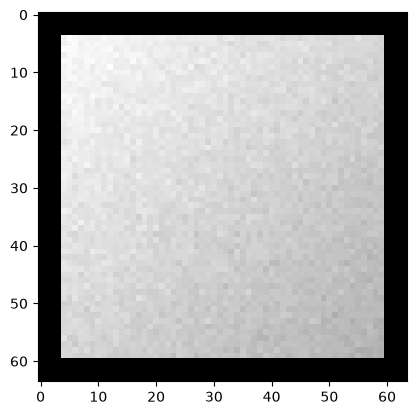

In [6]:
import matplotlib.pyplot as plt

red = img[:, :, 0]
plt.imshow(red, cmap="gray")
plt.show()


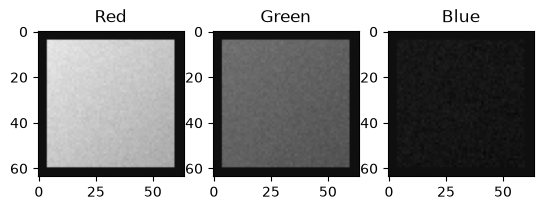

In [7]:
fig, axes = plt.subplots(1, 3)
names = ["Red", "Green", "Blue"]

for i in range(3):
    axes[i].imshow(img[:, :, i], cmap="gray", vmin=0, vmax=255)
    axes[i].set_title(names[i])

plt.show()


In [8]:
x = torch.from_numpy(img)

print(type(x))
print(x.shape)
print(x.dtype)


<class 'torch.Tensor'>
torch.Size([64, 64, 3])
torch.uint8


In [9]:
x = x.permute(2, 0, 1)
print(x.shape)


torch.Size([3, 64, 64])


In [10]:
x = x.float() / 255

print(x.dtype)
print(x.min().item(), x.max().item())
print(x[:, 32, 32])


torch.float32
0.019607843831181526 0.9215686321258545
tensor([0.7686, 0.4000, 0.0745])


In [11]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
print(hsv[32, 32])


[ 14 230 196]


In [12]:
print("bright corner  RGB:", img[8, 8],   "  HSV:", hsv[8, 8])
print("dim corner     RGB:", img[55, 55], "  HSV:", hsv[55, 55])


bright corner  RGB: [230 103  23]   HSV: [ 12 229 230]
dim corner     RGB: [171  83  24]   HSV: [ 12 219 171]


In [13]:
from pathlib import Path
import numpy as np

def sticker_hsv(path):
    bgr = cv2.imread(str(path))
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    return np.median(hsv.reshape(-1, 3), axis=0)   # the typical H, S, V of this sticker

for colour in ["white", "yellow", "red", "orange", "blue", "green"]:
    files = Path(f"data/stickers/train/{colour}").glob("*.png")
    hsvs = np.array([sticker_hsv(f) for f in files])
    print(f"{colour:<7} H {hsvs[:,0].min():3.0f}-{hsvs[:,0].max():3.0f}   S {hsvs[:,1].min():3.0f}-{hsvs[:,1].max():3.0f}   V {hsvs[:,2].min():3.0f}-{hsvs[:,2].max():3.0f}")


white   H  16- 80   S   2- 51   V 173-247
yellow  H  24- 26   S 218-253   V 228-252
red     H   3-  5   S 162-213   V 215-253
orange  H  11- 14   S 173-249   V 216-253
blue    H  36-105   S  16-184   V 166-244
green   H  47- 58   S 123-185   V 194-250


In [14]:
def classify_hsv(h, s):
    if s < 71:
        return "white"
    if h < 8:
        return "red"
    if h < 19:
        return "orange"
    if h < 37:
        return "yellow"
    if h < 79:
        return "green"
    if h < 143:
        return "blue"
    return "red"

print(classify_hsv(12, 229))
print(classify_hsv(36, 16))


orange
white


In [15]:
def evaluate(split):
    correct = 0
    total = 0
    for colour in ["white", "yellow", "red", "orange", "blue", "green"]:
        for f in Path(f"data/stickers/{split}/{colour}").glob("*.png"):
            h, s, v = sticker_hsv(f)
            guess = classify_hsv(h, s)
            if guess == colour:
                correct += 1
            total += 1
    print(f"{split}: {correct}/{total} correct = {correct / total:.1%}")

evaluate("train")
evaluate("test_normal")
evaluate("test_bad_light")


train: 422/424 correct = 99.5%
test_normal: 318/318 correct = 100.0%
test_bad_light: 212/212 correct = 100.0%
